
<div dir=ltr align=center>

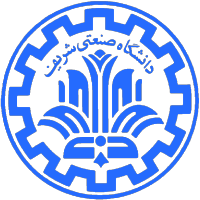

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Clustering: K-Means Clustering (Solution)<br>
<font color=696880 size=4>
    Prepared by Benyamin Ghanbari <br>

<font color=696880 size=2>
    Curated by Alireza Mirshafieian

____

### Image Segmentation Using K-Means Clustering for Color-Based Region Extraction

### Description: 

In this project, you will implement **K-Means clustering from scratch** and use it to perform image segmentation based on color similarity. **Image segmentation** is the process of dividing an image into meaningful regions. In this assignment, segmentation is done using **color clustering**, where every pixel is grouped into one of K color clusters.

**⚠️ Notice:** You are allowed to use **only the imported libraries** and must **follow the provided function structure**.



# 📝 **Project Instructions**

1. **Load the image**  
   Load the input image and convert it into an **RGB numerical array**.

2. **Reshape image to pixels**  
   Flatten the image into a **2D array**, where each row represents one pixel (**R, G, B**).

3. **Initialize K cluster centers**  
   Randomly select **K pixels** to serve as the starting cluster centers.

4. **Assign pixels to nearest cluster**  
   Compute **distances** and assign each pixel to the **closest cluster center**.

5. **Update cluster centers**  
   Recalculate each center as the **mean color** of all pixels assigned to that cluster.

6. **K-Means algorithm**  
   Repeat **assignment** and **update steps** until **convergence** or **max iterations**.

7. **Reconstruct segmented image**  
   Replace each pixel with the **color of its assigned cluster center**.

8. **Using the Elbow Method**  
   Compute the Compute Within-Cluster Sum of Squares **WCSS** for various **K values** to help estimate an **optimal K**.

9. **Run the segmentation**  
   Apply your **full K-Means pipeline** to segment the chosen image.

10. **Display results**  
    Plot and **visualize** the original and segmented images **side-by-side**.


# 📤 **Expected Output**

- A **segmented image** produced by your **K-Means implementation**  
- A **plot showing the Elbow Method curve** (**WCSS vs. K**)  
- **Observations** about how changing **K** affects segmentation


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [12]:

# Step 1: Load the image

def load_image(path):
    image = Image.open(path)
    image = image.convert("RGB")
    data = np.array(image)
    return data


# Step 2: Reshape image to pixels

def preprocess_image(image_data):
    pixels = image_data.reshape(-1, 3)
    return pixels



In [25]:

# Step 3: Initialize K cluster centers

def initialize_centers(pixels, k):
    np.random.seed(42)
    indices = np.random.choice(pixels.shape[0], k, replace=False)
    centers = pixels[indices]
    return centers


# Step 4: Assign pixels to nearest cluster

def assign_clusters(pixels, centers):
    distances = np.linalg.norm(pixels[:, np.newaxis] - centers, axis=2)
    labels = np.argmin(distances, axis=1)
    return labels


# Step 5: Update cluster centers
    
def update_centers(pixels, labels, k):
    new_centers = []
    for i in range(k):
        cluster_points = pixels[labels == i]
        
        if len(cluster_points) == 0:
            # Reinitialize empty cluster to a random pixel
            new_center = pixels[np.random.randint(len(pixels))]
        else:
            new_center = cluster_points.mean(axis=0)
        
        new_centers.append(new_center)
    
    return np.array(new_centers)



# Step 6: K-Means algorithm

def kmeans(pixels, k, max_iters=10, tol=1e-4):
    centers = initialize_centers(pixels, k)
    for i in range(max_iters):
        labels = assign_clusters(pixels, centers)
        new_centers = update_centers(pixels, labels, k)
        if np.all(np.abs(new_centers - centers) < tol):
            break
        centers = new_centers
    return centers, labels

In [26]:

# Step 7: Reconstruct segmented image

def recreate_image(labels, centers, image_shape):
    segmented = centers[labels].reshape(image_shape).astype(np.uint8)
    return segmented

In [27]:

if __name__ == "__main__":
    image_path = "shrek_and_princess_fiona.jpg"  
    image_data = load_image(image_path)
    pixels = preprocess_image(image_data)

In [28]:

# Elbow Method

def calculate_wcss(pixels, max_k=10):
    wcss = []
    for k in range(1, max_k + 1):
        centers, labels = kmeans(pixels, k)
        # Compute Within-Cluster Sum of Squares (WCSS)
        distances = np.linalg.norm(pixels - centers[labels], axis=1)
        wcss.append(np.sum(distances))
    return wcss

def plot_elbow(wcss):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(wcss) + 1), wcss, marker='o')
    plt.title("Elbow Method for Optimal K")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("WCSS")
    plt.grid(True)
    plt.show()


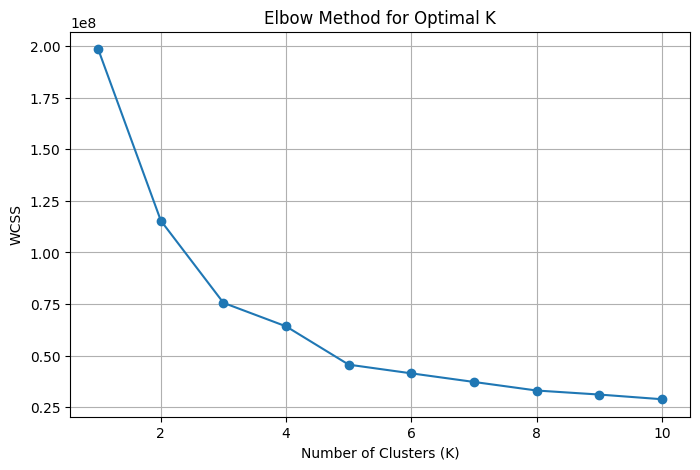

In [29]:
wcss = calculate_wcss(pixels, max_k=10)
plot_elbow(wcss)

In [30]:

# Step 8: Run the segmentation

k = 5
centers, labels = kmeans(pixels, k)
segmented_image = recreate_image(labels, centers, image_data.shape)


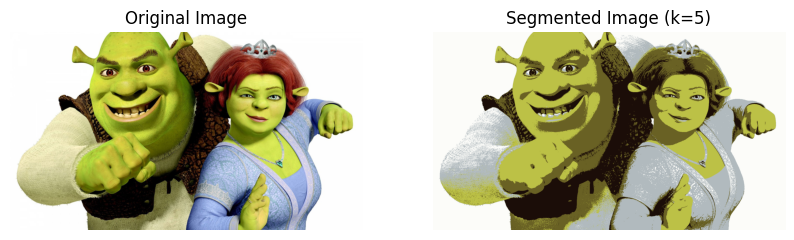

In [31]:
# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image_data)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Segmented Image (k={k})")
plt.imshow(segmented_image)
plt.axis('off')
plt.show()